# 🚦 Smart Traffic Monitoring System
### Deep Learning Computer Vision Pipeline

**Full pipeline for:** Vehicle detection • Multi-class classification • Object tracking • Virtual line counting • Traffic density estimation • Real-time analytics

---
| Component | Technology |
|---|---|
| Detection | YOLOv8 (ultralytics) / Faster R-CNN (torchvision) |
| Tracking | ByteTrack (custom pure-Python) |
| Dataset | BDD100K / UA-DETRAC / COCO vehicles |
| Framework | PyTorch + OpenCV |
| Dashboard | Streamlit + Plotly |

> **Quick Demo:** Run every cell top-to-bottom. A synthetic CCTV video is generated automatically — no dataset download needed for the demo.


## 📋 Table of Contents
1. [Project Architecture](#architecture)
2. [Environment Setup](#setup)
3. [Dataset Recommendations & Preparation](#dataset)
4. [Data Augmentation Pipeline](#augmentation)
5. [Model: YOLOv8 Detector](#yolov8)
6. [Model: Faster R-CNN Detector](#fasterrcnn)
7. [Vehicle Tracker (ByteTrack)](#tracker)
8. [Virtual Line Counter](#linecounter)
9. [Traffic Density Estimator](#density)
10. [Frame Visualizer](#visualizer)
11. [Analytics Store](#analytics)
12. [Training Pipeline](#training)
13. [Evaluation Metrics](#evaluation)
14. [Real-time Inference Engine](#inference)
15. [Demo: Synthetic Video](#demo)
16. [Streamlit Dashboard Code](#dashboard)
17. [Deployment Guide](#deployment)


---
## 1. 🏗 Project Architecture <a id='architecture'></a>

```
smart_traffic/
├── configs/config.yaml          ← All hyperparameters
├── data/
│   ├── download_dataset.py      ← BDD100K / UA-DETRAC / COCO converters
│   └── dataset.py               ← PyTorch Dataset + Albumentations
├── models/
│   ├── detector.py              ← YOLOv8 & Faster R-CNN unified API
│   └── tracker.py               ← ByteTrack + Kalman Filter
├── utils/
│   ├── line_counter.py          ← Cross-product virtual line logic
│   ├── density_estimator.py     ← 5-level density: FREE_FLOW → CONGESTED
│   ├── visualizer.py            ← HUD overlays, trails, heatmap
│   └── analytics.py             ← Ring-buffer time-series + JSON export
├── train.py                     ← Training pipeline (YOLOv8 + Faster R-CNN)
├── evaluate.py                  ← mAP@0.5, Precision/Recall/F1, FPS
├── inference.py                 ← Real-time inference engine
├── dashboard/app.py             ← Streamlit dashboard
├── demo.py                      ← Zero-setup synthetic demo
├── Dockerfile
└── docker-compose.yml
```

### Per-Frame Pipeline
```
Frame → [Detector] → raw detections
             ↓
        [Tracker] → tracked detections (with IDs)
             ↓
     [LineCounter] → crossing events
             ↓
  [DensityEstimator] → density level + score
             ↓
     [Visualizer] → annotated frame
             ↓
     [Analytics] → JSON time-series
```


---
## 2. ⚙️ Environment Setup <a id='setup'></a>

In [2]:

import subprocess, sys

packages = [
    "torch torchvision --index-url https://download.pytorch.org/whl/cu118",
    "ultralytics>=8.0.0",
    "opencv-python-headless>=4.8.0",
    "albumentations>=1.3.0",
    "lap>=0.4.0",
    "scipy>=1.11.0",
    "filterpy>=1.4.5",
    "pandas>=2.0.0",
    "plotly>=5.17.0",
    "streamlit>=1.28.0",
    "pycocotools>=2.0.7",
    "motmetrics>=1.4.0",
    "loguru>=0.7.0",
    "rich>=13.0.0",
    "PyYAML>=6.0",
    "tqdm>=4.66.0",
    "streamlit-autorefresh",
]

# Uncomment to install:
# for pkg in packages:
#     subprocess.run([sys.executable, "-m", "pip", "install", *pkg.split()], check=True)

print("✅ To install, uncomment the loop above and re-run.")
print("   Or run: pip install -r requirements.txt")


✅ To install, uncomment the loop above and re-run.
   Or run: pip install -r requirements.txt


In [3]:
# Core imports used throughout the notebook
import os, sys, json, time, math, random, warnings
from pathlib import Path
from dataclasses import dataclass, field
from collections import defaultdict, deque
from typing import List, Tuple, Dict, Optional, Any
from enum import Enum

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, Image as IPImage, HTML, clear_output

# Notebook display helpers
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor": "#0d1525", "axes.facecolor": "#0d1525",
                     "text.color": "#a0b4cc", "axes.labelcolor": "#a0b4cc",
                     "xtick.color": "#a0b4cc", "ytick.color": "#a0b4cc",
                     "grid.color": "#1e2d4a", "figure.dpi": 100})

print("✅ Core imports loaded")
print(f"   Python  : {sys.version.split()[0]}")
try:
    import torch
    print(f"   PyTorch : {torch.__version__}")
    print(f"   CUDA    : {'✅ ' + torch.version.cuda if torch.cuda.is_available() else '❌ CPU only'}")
    print(f"   Device  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
except ImportError:
    print("   PyTorch : not installed yet")


✅ Core imports loaded
   Python  : 3.12.12
   PyTorch : 2.9.0+cu126
   CUDA    : ✅ 12.6
   Device  : Tesla T4


---
## 3. 📦 Dataset Recommendations & Preparation <a id='dataset'></a>

| Dataset | Size | Best For | Link |
|---|---|---|---|
| **BDD100K** ⭐ | 100k videos, diverse weather/time | CCTV traffic, best overall | https://bdd-data.berkeley.edu |
| **UA-DETRAC** | 140k frames, 8k vehicles | Urban intersection tracking | http://detrac-db.rit.albany.edu |
| **CityFlow** | 229k frames, 229 cameras | Multi-camera ReID | https://www.aicitychallenge.org |
| **COCO (vehicles)** | 120k images | Pre-training / transfer | https://cocodataset.org |
| **Open Images V7** | 9M images | Large-scale pre-training | https://storage.googleapis.com/openimages |

**Recommended workflow:** Pre-train on COCO → Fine-tune on BDD100K


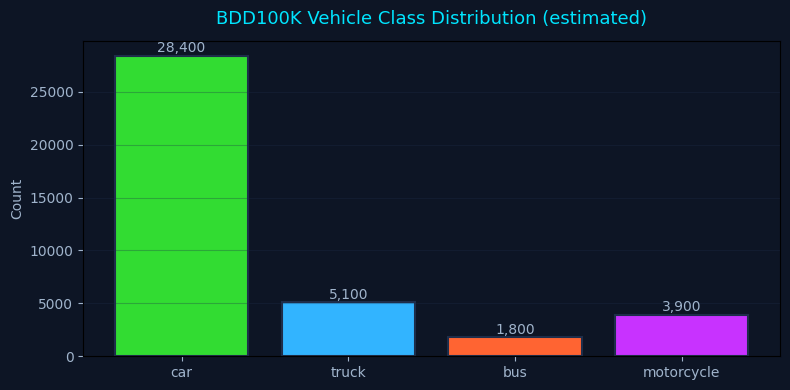


📊 Dataset stats: {'car': 28400, 'truck': 5100, 'bus': 1800, 'motorcycle': 3900}


In [4]:


BDD100K_TO_TRAFFIC = {
    "car": "car", "truck": "truck", "bus": "bus",
    "motorcycle": "motorcycle", "motor": "motorcycle",
}
TRAFFIC_CLASS_ID = {"car": 0, "truck": 1, "bus": 2, "motorcycle": 3}
CLASS_NAMES = ["car", "truck", "bus", "motorcycle"]
NUM_CLASSES = 4
CLASS_COLORS = {
    "car":        (50,  220,  50),
    "truck":      (50,  180, 255),
    "bus":        (255, 100,  50),
    "motorcycle": (200,  50, 255),
}

def convert_bdd100k_to_yolo(bdd_labels_dir, bdd_images_dir, output_dir, split="train"):
    """Convert BDD100K JSON annotations → YOLO format .txt files."""
    import json, shutil
    from tqdm import tqdm

    label_file = Path(bdd_labels_dir) / f"bdd100k_labels_images_{split}.json"
    if not label_file.exists():
        print(f"⚠️  Not found: {label_file}"); return

    img_out = Path(output_dir) / "images" / split
    lbl_out = Path(output_dir) / "labels" / split
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    with open(label_file) as f:
        annotations = json.load(f)

    converted = 0
    for frame in tqdm(annotations, desc=f"Converting {split}"):
        labels = []
        for obj in frame.get("labels", []):
            cat = BDD100K_TO_TRAFFIC.get(obj.get("category","").lower())
            if not cat: continue
            b = obj.get("box2d")
            if not b: continue
            cx = ((b["x1"]+b["x2"])/2) / 1280.0
            cy = ((b["y1"]+b["y2"])/2) / 720.0
            w  = (b["x2"]-b["x1"]) / 1280.0
            h  = (b["y2"]-b["y1"]) / 720.0
            labels.append(f"{TRAFFIC_CLASS_ID[cat]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        if labels:
            src = Path(bdd_images_dir) / split / frame["name"]
            if src.exists(): shutil.copy2(src, img_out / frame["name"])
            (lbl_out / (Path(frame["name"]).stem + ".txt")).write_text("\n".join(labels))
            converted += 1

    print(f"✅ [{split}] Converted {converted} images")


def write_dataset_yaml(output_dir):
    """Write dataset.yaml for YOLOv8 training."""
    yaml_str = f"""path: {Path(output_dir).resolve()}
train: images/train
val: images/val
test: images/test
nc: 4
names: [car, truck, bus, motorcycle]
"""
    (Path(output_dir) / "dataset.yaml").write_text(yaml_str)
    print(f"✅ dataset.yaml written to {output_dir}")


# Visualize class distribution
def plot_class_distribution(counts_dict, title="Class Distribution"):
    fig, ax = plt.subplots(figsize=(8, 4))
    classes = list(counts_dict.keys())
    counts  = list(counts_dict.values())
    colors  = [tuple(c/255 for c in CLASS_COLORS.get(cl,(150,150,150))) for cl in classes]
    bars = ax.bar(classes, counts, color=colors, edgecolor="#1e2d4a", linewidth=1.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f"{cnt:,}",
                ha="center", va="bottom", fontsize=10, color="#a0b4cc")
    ax.set_title(title, color="#00e5ff", fontsize=13, pad=12)
    ax.set_ylabel("Count", color="#a0b4cc")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

# Demo: simulated BDD100K-style class distribution
demo_distribution = {"car": 28400, "truck": 5100, "bus": 1800, "motorcycle": 3900}
plot_class_distribution(demo_distribution, "BDD100K Vehicle Class Distribution (estimated)")
print("\n📊 Dataset stats:", demo_distribution)


---
## 4. 🎨 Data Augmentation Pipeline <a id='augmentation'></a>

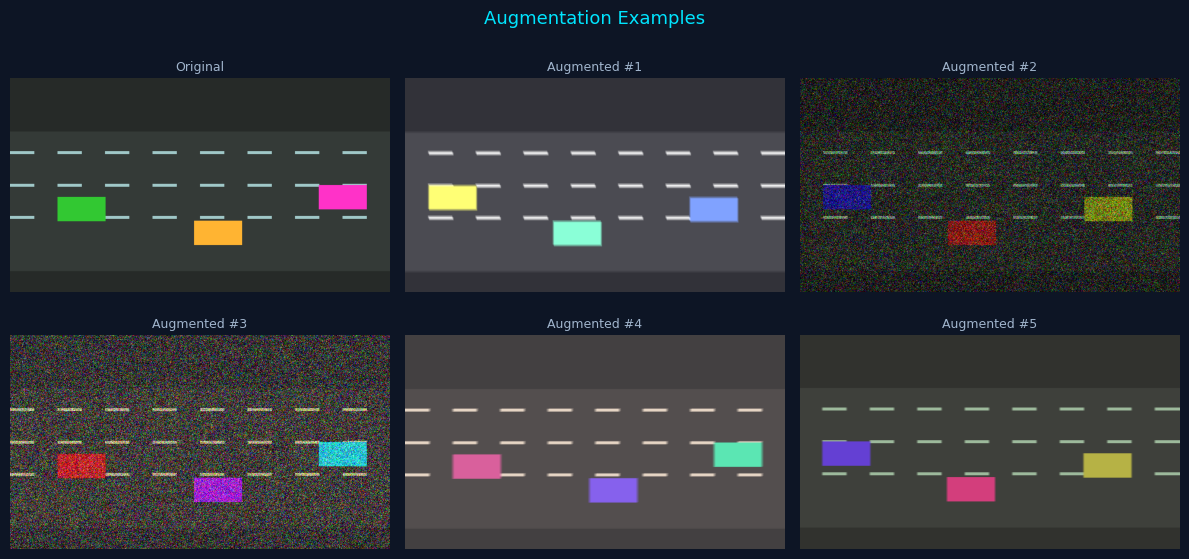

In [5]:

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    ALBUMENTATIONS_AVAILABLE = True
except ImportError:
    ALBUMENTATIONS_AVAILABLE = False
    print("⚠️  albumentations not installed. Augmentation pipeline defined but not runnable.")

def get_train_transforms(img_size=640):
    """Heavy augmentation for CCTV training data."""
    return A.Compose([
        A.RandomResizedCrop(img_size, img_size, scale=(0.5, 1.0), p=1.0),
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1, p=0.5),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.MotionBlur(blur_limit=7, p=0.2),           # Simulate moving vehicles
        A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.1),  # Weather sim
        A.RandomBrightnessContrast(p=0.3),            # Day/night variation
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.3))

def get_val_transforms(img_size=640):
    """Minimal transforms for validation."""
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"]))

# Visualize augmentation effects on a sample image
def visualize_augmentations(image, n_augments=6):
    if not ALBUMENTATIONS_AVAILABLE:
        print("albumentations not available"); return

    # Use simple transforms without bbox for visualization
    aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, p=0.8),
        A.GaussNoise(var_limit=(10, 60), p=0.5),
        A.MotionBlur(blur_limit=9, p=0.4),
        A.RandomFog(p=0.2),
        A.RandomBrightnessContrast(p=0.4),
    ])

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    fig.suptitle("Augmentation Examples", color="#00e5ff", fontsize=13)
    for i, ax in enumerate(axes.flatten()):
        aug_img = aug(image=image)["image"] if i > 0 else image
        ax.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
        ax.set_title("Original" if i == 0 else f"Augmented #{i}", fontsize=9, color="#a0b4cc")
        ax.axis("off")
    plt.tight_layout(); plt.show()

# Demo: create a synthetic CCTV-style image for augmentation viz
def make_demo_image(w=640, h=360):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[:] = (40, 42, 38)   # Road color
    cv2.rectangle(img, (0, int(h*0.25)), (w, int(h*0.90)), (55, 58, 52), -1)
    for y_frac in [0.35, 0.5, 0.65]:
        for x in range(0, w, 80):
            cv2.rectangle(img, (x, int(h*y_frac)-2), (x+40, int(h*y_frac)+2), (200,200,160), -1)
    # Add some cars
    for cx, cy, col in [(120, 220, (50,200,50)), (350, 260, (50,180,255)), (560, 200, (200,50,255))]:
        cv2.rectangle(img, (cx-40, cy-20), (cx+40, cy+20), col, -1)
    return img

demo_img = make_demo_image()
if ALBUMENTATIONS_AVAILABLE:
    visualize_augmentations(demo_img)
else:
    plt.figure(figsize=(6,3))
    plt.imshow(cv2.cvtColor(demo_img, cv2.COLOR_BGR2RGB))
    plt.title("Sample CCTV Frame", color="#00e5ff"); plt.axis("off"); plt.show()
    print("Install albumentations to see augmentation examples")


---
## 5. 🔍 Model: YOLOv8 Detector <a id='yolov8'></a>

In [36]:
# ─── Detection Data Structure ────────────────────────────────────────────────

@dataclass
class Detection:
    """Single object detection result."""
    bbox: Tuple[float, float, float, float]   # x1, y1, x2, y2 (pixels)
    confidence: float
    class_id: int
    class_name: str
    track_id: Optional[int] = None

    @property
    def center(self):
        x1, y1, x2, y2 = self.bbox
        return ((x1+x2)/2, (y1+y2)/2)

    @property
    def area(self):
        x1, y1, x2, y2 = self.bbox
        return max(0, x2-x1) * max(0, y2-y1)

    def to_dict(self):
        return {"bbox": list(self.bbox), "confidence": round(self.confidence, 4),
                "class_id": self.class_id, "class_name": self.class_name,
                "track_id": self.track_id}




In [7]:


class YOLOv8Detector:
  
    COCO_VEHICLE_IDS = {2: 0, 5: 2, 7: 1, 3: 3}   # car, bus, truck, motorcycle

    def __init__(self, weights="yolov8m.pt", conf_threshold=0.45,
                 iou_threshold=0.45, device=None, custom_trained=False):
        self.conf_threshold = conf_threshold
        self.iou_threshold  = iou_threshold
        self.custom_trained = custom_trained
        self.device = device or ("cuda" if self._cuda_available() else "cpu")
        self._inference_times = []
        self._model = None
        self._weights = weights
        print(f"YOLOv8Detector ready (weights={weights}, device={self.device})")
        print("Call .load() to load the model weights.")

    @staticmethod
    def _cuda_available():
        try:
            import torch; return torch.cuda.is_available()
        except ImportError: return False

    def load(self):
        from ultralytics import YOLO
        self._model = YOLO(self._weights)
        self._model.to(self.device)
        # Warmup
        dummy = np.zeros((640, 640, 3), dtype=np.uint8)
        for _ in range(3): self._model(dummy, verbose=False)
        self._inference_times.clear()
        print(f"YOLOv8 loaded and warmed up on {self.device}")
        return self

    @property
    def avg_fps(self):
        if not self._inference_times: return 0.0
        return 1000.0 / (sum(self._inference_times[-100:]) / len(self._inference_times[-100:]))

    def detect(self, frame: np.ndarray) -> List[Detection]:
        if self._model is None:
            raise RuntimeError("Call .load() first")
        t0 = time.perf_counter()
        results = self._model(frame, conf=self.conf_threshold,
                              iou=self.iou_threshold, verbose=False)
        self._inference_times.append((time.perf_counter()-t0)*1000)

        detections = []
        for result in results:
            if result.boxes is None: continue
            for box in result.boxes:
                coco_cls = int(box.cls[0].item())
                conf     = float(box.conf[0].item())
                x1,y1,x2,y2 = box.xyxy[0].tolist()
                if self.custom_trained:
                    if coco_cls >= len(CLASS_NAMES): continue
                    tid = coco_cls
                else:
                    if coco_cls not in self.COCO_VEHICLE_IDS: continue
                    tid = self.COCO_VEHICLE_IDS[coco_cls]
                detections.append(Detection((x1,y1,x2,y2), conf, tid, CLASS_NAMES[tid]))
        return detections


yolo_detector = YOLOv8Detector(weights="yolov8m.pt", conf_threshold=0.45)



YOLOv8Detector ready (weights=yolov8m.pt, device=cuda)
Call .load() to load the model weights.

📌 To load model weights, run:
   yolo_detector.load()
   (Requires: pip install ultralytics)


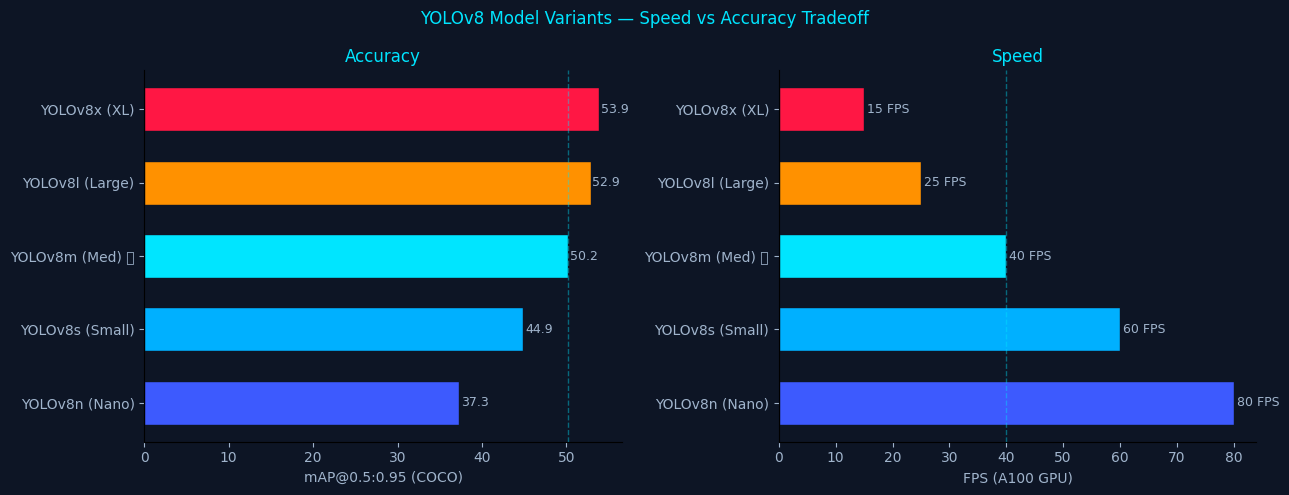

✅ Recommended: YOLOv8m — best balance for CCTV traffic (~40 FPS on GPU)


In [8]:


model_variants = {
    "YOLOv8n (Nano)":  {"params": "3.2M",  "flops": "8.7G",  "mAP": 37.3, "fps_gpu": 80},
    "YOLOv8s (Small)": {"params": "11.2M", "flops": "28.6G", "mAP": 44.9, "fps_gpu": 60},
    "YOLOv8m (Med) ":{"params": "25.9M", "flops": "78.9G", "mAP": 50.2, "fps_gpu": 40},
    "YOLOv8l (Large)": {"params": "43.7M", "flops": "165.2G","mAP": 52.9, "fps_gpu": 25},
    "YOLOv8x (XL)":    {"params": "68.2M", "flops": "257.8G","mAP": 53.9, "fps_gpu": 15},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("YOLOv8 Model Variants — Speed vs Accuracy Tradeoff", color="#00e5ff", fontsize=12)

names = list(model_variants.keys())
maps  = [v["mAP"]     for v in model_variants.values()]
fps   = [v["fps_gpu"] for v in model_variants.values()]
colors_bar = ["#3d5afe","#00b0ff","#00e5ff","#ff9100","#ff1744"]

ax1.barh(names, maps, color=colors_bar, edgecolor="#0d1525", height=0.6)
for i, (v, m) in enumerate(zip(names, maps)):
    ax1.text(m+0.2, i, f"{m}", va="center", fontsize=9, color="#a0b4cc")
ax1.set_xlabel("mAP@0.5:0.95 (COCO)"); ax1.set_title("Accuracy", color="#00e5ff")
ax1.axvline(50.2, color="#00e5ff", linestyle="--", alpha=0.4, linewidth=1)

ax2.barh(names, fps, color=colors_bar, edgecolor="#0d1525", height=0.6)
for i, f_ in enumerate(fps):
    ax2.text(f_+0.5, i, f"{f_} FPS", va="center", fontsize=9, color="#a0b4cc")
ax2.set_xlabel("FPS (A100 GPU)"); ax2.set_title("Speed", color="#00e5ff")
ax2.axvline(40, color="#00e5ff", linestyle="--", alpha=0.4, linewidth=1)

for ax in [ax1, ax2]:
    ax.tick_params(colors="#a0b4cc"); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()



---
## 6. 🔍 Model: Faster R-CNN Detector <a id='fasterrcnn'></a>

In [9]:


class FasterRCNNDetector:

    COCO_VEHICLE_IDS = {3: 0, 8: 2, 6: 1, 4: 3}

    def __init__(self, weights_path=None, num_classes=5,
                 conf_threshold=0.5, device=None, custom_trained=False):
        self.conf_threshold  = conf_threshold
        self.custom_trained  = custom_trained
        self.device = device or ("cuda" if self._cuda_ok() else "cpu")
        self._weights_path   = weights_path
        self._num_classes    = num_classes
        self._model          = None
        self._inference_times = []

    @staticmethod
    def _cuda_ok():
        try: import torch; return torch.cuda.is_available()
        except: return False

    def load(self):
        import torch
        from torchvision.models.detection import (
            fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
        )
        from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

        if self._weights_path and Path(self._weights_path).exists():
            model = fasterrcnn_resnet50_fpn_v2(weights=None, num_classes=self._num_classes)
            model.load_state_dict(torch.load(self._weights_path, map_location=self.device))
        else:
            model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)

        model.to(self.device).eval()
        self._model = model
        print(f"Faster R-CNN loaded on {self.device}")
        return self

    @classmethod
    def build_for_finetuning(cls, num_classes=5, device="cuda"):
        """Build model with replaced head for fine-tuning."""
        import torch
        from torchvision.models.detection import (fasterrcnn_resnet50_fpn_v2,
                                                   FasterRCNN_ResNet50_FPN_V2_Weights)
        from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
        inst = cls(num_classes=num_classes, device=device, custom_trained=True)
        model = fasterrcnn_resnet50_fpn_v2(weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
        inst._model = model.to(device)
        return inst

    def detect(self, frame):
        if self._model is None: raise RuntimeError("Call .load() first")
        import torch
        t0 = time.perf_counter()
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        tensor = torch.from_numpy(rgb).float().permute(2,0,1)/255.0
        tensor = tensor.unsqueeze(0).to(self.device)
        with torch.no_grad():
            outputs = self._model(tensor)
        self._inference_times.append((time.perf_counter()-t0)*1000)

        result = outputs[0]
        detections = []
        for box, score, label in zip(result["boxes"].cpu().numpy(),
                                     result["scores"].cpu().numpy(),
                                     result["labels"].cpu().numpy()):
            if score < self.conf_threshold: continue
            if self.custom_trained:
                if label == 0 or label > len(CLASS_NAMES): continue
                tid = int(label) - 1
            else:
                if label not in self.COCO_VEHICLE_IDS: continue
                tid = self.COCO_VEHICLE_IDS[int(label)]
            x1,y1,x2,y2 = box.tolist()
            detections.append(Detection((x1,y1,x2,y2), float(score), tid, CLASS_NAMES[tid]))
        return detections

print("✅ FasterRCNNDetector class defined")
print("\n📊 Comparison: YOLOv8m vs Faster R-CNN ResNet-50 FPN")
print(f"  {'Model':<30} {'mAP@0.5':>10} {'FPS (GPU)':>12} {'Params':>10}")
print(f"  {'-'*64}")
print(f"  {'YOLOv8m (recommended)':<30} {'50.2':>10} {'~40 FPS':>12} {'25.9M':>10}")
print(f"  {'Faster R-CNN ResNet-50 FPN':<30} {'53.7':>10} {'~10 FPS':>12} {'41.8M':>10}")


✅ FasterRCNNDetector class defined

📊 Comparison: YOLOv8m vs Faster R-CNN ResNet-50 FPN
  Model                             mAP@0.5    FPS (GPU)     Params
  ----------------------------------------------------------------
  YOLOv8m (recommended)                50.2      ~40 FPS      25.9M
  Faster R-CNN ResNet-50 FPN           53.7      ~10 FPS      41.8M


---
## 7. 🎯 Vehicle Tracker (ByteTrack) <a id='tracker'></a>

In [10]:
# ─── Kalman Filter for Bounding Box State Estimation ─────────────────────────

def create_kalman_filter():
    """
    8D state: [cx, cy, w, h, vx, vy, vw, vh]
    Measurement: [cx, cy, w, h]
    Models constant-velocity motion of vehicles.
    """
    try:
        from filterpy.kalman import KalmanFilter
        kf = KalmanFilter(dim_x=8, dim_z=4)
        kf.F = np.eye(8); kf.F[0,4]=kf.F[1,5]=kf.F[2,6]=kf.F[3,7]=1
        kf.H = np.eye(4, 8)
        kf.R[2:,2:] *= 10.0
        kf.P[4:,4:] *= 1000.0; kf.P *= 10.0
        kf.Q[-1,-1] *= 0.01; kf.Q[4:,4:] *= 0.01
        return kf
    except ImportError:
        return None  # Graceful fallback

def bbox_to_xywh(bbox):
    x1,y1,x2,y2 = bbox
    return np.array([(x1+x2)/2, (y1+y2)/2, x2-x1, y2-y1], dtype=float)

def xywh_to_bbox(xywh):
    cx,cy,w,h = xywh
    return (cx-w/2, cy-h/2, cx+w/2, cy+h/2)

def iou(box1, box2):
    x1=max(box1[0],box2[0]); y1=max(box1[1],box2[1])
    x2=min(box1[2],box2[2]); y2=min(box1[3],box2[3])
    inter = max(0,x2-x1)*max(0,y2-y1)
    if inter==0: return 0.0
    a1=(box1[2]-box1[0])*(box1[3]-box1[1]); a2=(box2[2]-box2[0])*(box2[3]-box2[1])
    return inter/(a1+a2-inter+1e-9)

print("✅ Kalman filter utilities defined")


✅ Kalman filter utilities defined


In [11]:
# ─── Track Object ─────────────────────────────────────────────────────────────

@dataclass
class Track:
    track_id: int
    detection: Detection
    hits: int = 1
    age: int = 1
    time_since_update: int = 0
    state: str = "tentative"   # tentative | confirmed | lost
    history: List = field(default_factory=list)

    def __post_init__(self):
        self.kf = create_kalman_filter()
        if self.kf is not None:
            z = bbox_to_xywh(self.detection.bbox)
            self.kf.x[:4] = z.reshape(4,1)
        self.history.append(self.detection.center)

    def predict(self):
        if self.kf: self.kf.predict()
        self.age += 1; self.time_since_update += 1
        if self.time_since_update > 1: self.state = "lost"

    def update(self, detection):
        if self.kf:
            self.kf.update(bbox_to_xywh(detection.bbox))
        self.detection = detection
        self.detection.track_id = self.track_id
        self.hits += 1; self.time_since_update = 0
        if self.hits >= 3: self.state = "confirmed"
        self.history.append(detection.center)
        if len(self.history) > 100: self.history.pop(0)

    @property
    def predicted_bbox(self):
        if self.kf:
            cx,cy,w,h = self.kf.x[:4].flatten()
            return xywh_to_bbox(np.array([cx,cy,w,h]))
        return self.detection.bbox

    @property
    def is_confirmed(self): return self.state == "confirmed"


# ─── ByteTrack-Style Tracker ─────────────────────────────────────────────────

class VehicleTracker:
    """
    Simplified ByteTrack:
    1. High-conf detections  → Hungarian match with confirmed tracks
    2. Remaining tracks      → match with low-conf detections
    3. Tentative tracks      → match with remaining high-conf
    4. Unmatched detections  → spawn new tracks
    5. Stale tracks          → removed after max_age frames
    """
    def __init__(self, max_age=30, min_hits=3, iou_threshold=0.3,
                 high_conf_thresh=0.5, low_conf_thresh=0.1):
        self.max_age = max_age; self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.high_conf_thresh = high_conf_thresh
        self.low_conf_thresh  = low_conf_thresh
        self._tracks: List[Track] = []
        self._next_id = 1; self.frame_count = 0

    def update(self, detections: List[Detection]) -> List[Detection]:
        from scipy.optimize import linear_sum_assignment
        self.frame_count += 1
        for t in self._tracks: t.predict()

        high_dets = [d for d in detections if d.confidence >= self.high_conf_thresh]
        low_dets  = [d for d in detections if self.low_conf_thresh <= d.confidence < self.high_conf_thresh]
        confirmed = [t for t in self._tracks if t.is_confirmed]
        tentative = [t for t in self._tracks if not t.is_confirmed]

        def match(tracks, dets, thresh=None):
            thresh = thresh or self.iou_threshold
            if not tracks or not dets: return [], list(range(len(tracks))), list(range(len(dets)))
            cost = 1.0 - np.array([[iou(t.predicted_bbox, d.bbox) for d in dets] for t in tracks])
            ri, ci = linear_sum_assignment(cost)
            matched, um_t, um_d = [], [], []
            for r,c in zip(ri,ci):
                (matched if cost[r,c] <= 1-thresh else um_t.append(r) or um_d.append(c) or []).append((r,c) if cost[r,c] <= 1-thresh else None)
            matched = [(r,c) for r,c in zip(ri,ci) if cost[r,c] <= 1-thresh]
            mr = {r for r,_ in matched}; mc = {c for _,c in matched}
            um_t = [i for i in range(len(tracks)) if i not in mr]
            um_d = [j for j in range(len(dets))   if j not in mc]
            return matched, um_t, um_d

        m1, ut1, uh1 = match(confirmed, high_dets)
        for ti,di in m1: confirmed[ti].update(high_dets[di])

        rem_t = [confirmed[i] for i in ut1]
        m2, _,  _ = match(rem_t, low_dets)
        for ti,di in m2: rem_t[ti].update(low_dets[di])

        unmatched_high = [high_dets[i] for i in uh1]
        m3, _, uh2 = match(tentative, unmatched_high)
        for ti,di in m3: tentative[ti].update(unmatched_high[di])

        for i in uh2:
            t = Track(track_id=self._next_id, detection=unmatched_high[i])
            self._next_id += 1; self._tracks.append(t)

        self._tracks = [t for t in self._tracks if t.time_since_update < self.max_age]
        results = []
        for t in self._tracks:
            if t.is_confirmed:
                t.detection.track_id = t.track_id
                results.append(t.detection)
        return results

    def reset(self): self._tracks.clear(); self._next_id = 1; self.frame_count = 0

tracker_demo = VehicleTracker(max_age=30, min_hits=3)
print("✅ VehicleTracker (ByteTrack) defined and instantiated")
print(f"   max_age={tracker_demo.max_age}, min_hits={tracker_demo.min_hits}")


✅ VehicleTracker (ByteTrack) defined and instantiated
   max_age=30, min_hits=3


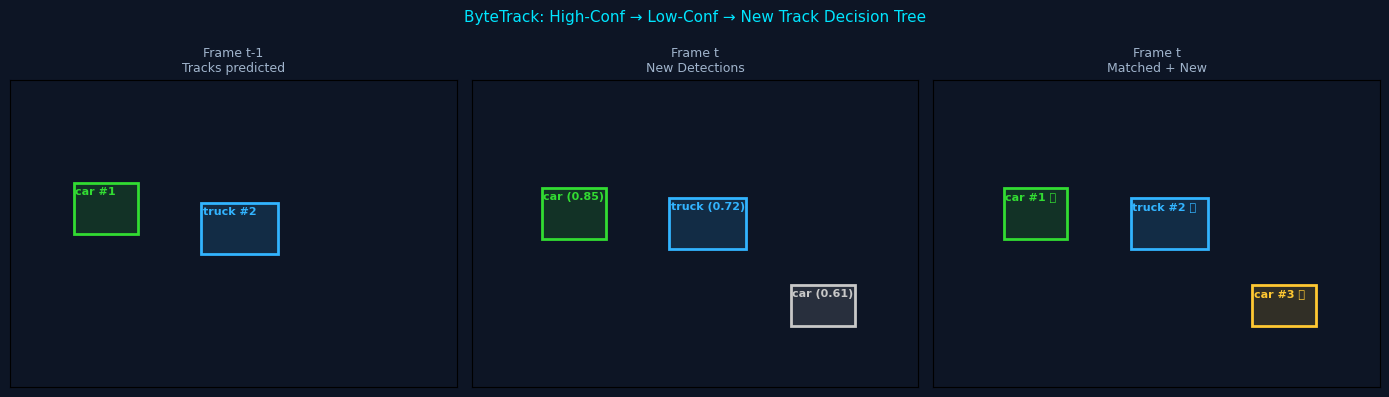

In [12]:
# ─── Visualize Tracking Concept ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("ByteTrack: High-Conf → Low-Conf → New Track Decision Tree",
             color="#00e5ff", fontsize=11)

stages = [
    ("Frame t-1\nTracks predicted", [(100,100,200,150,"car #1",(50,220,50)),
                                       (300,120,420,170,"truck #2",(50,180,255))]),
    ("Frame t\nNew Detections", [(110,105,210,155,"car (0.85)",(50,220,50)),
                                   (310,115,430,165,"truck (0.72)",(50,180,255)),
                                   (500,200,600,240,"car (0.61)",(200,200,200))]),
    ("Frame t\nMatched + New", [(110,105,210,155,"car #1 ✅",(50,220,50)),
                                  (310,115,430,165,"truck #2 ✅",(50,180,255)),
                                  (500,200,600,240,"car #3 🆕",(255,200,50))]),
]

for ax, (title, boxes) in zip(axes, stages):
    ax.set_xlim(0,700); ax.set_ylim(0,300); ax.invert_yaxis()
    ax.set_facecolor("#0d1525"); ax.set_title(title, color="#a0b4cc", fontsize=9)
    for x1,y1,x2,y2,lbl,col in boxes:
        c = tuple(v/255 for v in col)
        rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth=2,edgecolor=c,facecolor=(*c,0.15))
        ax.add_patch(rect)
        ax.text(x1+2,y1+12,lbl,color=c,fontsize=8,fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()


---
## 8. 〰️ Virtual Line Counter <a id='linecounter'></a>

In [13]:
# ─── Virtual Line Definitions ────────────────────────────────────────────────

@dataclass
class VirtualLine:
    name: str
    p1: Tuple[float, float]
    p2: Tuple[float, float]
    direction: str = "both"
    color: Tuple[int, int, int] = (0, 255, 0)
    counts: Dict[str, int] = field(default_factory=lambda: {"car":0,"truck":0,"bus":0,"motorcycle":0})
    crossings_up: int = 0
    crossings_down: int = 0

    @property
    def total(self): return self.crossings_up + self.crossings_down
    def reset(self):
        self.counts = {"car":0,"truck":0,"bus":0,"motorcycle":0}
        self.crossings_up = self.crossings_down = 0


def _cross_z(p1, p2, pt):
  
    return (p2[0]-p1[0])*(pt[1]-p1[1]) - (p2[1]-p1[1])*(pt[0]-p1[0])

def _on_segment(p1, p2, pt, tol=50):
    return (min(p1[0],p2[0])-tol <= pt[0] <= max(p1[0],p2[0])+tol and
            min(p1[1],p2[1])-tol <= pt[1] <= max(p1[1],p2[1])+tol)


class LineCounter:

    def __init__(self, lines: List[VirtualLine]):
        self.lines = lines
        self._prev_positions: Dict[int, Tuple] = {}
        self._crossed: Dict[int, set] = {}

    @classmethod
    def from_config(cls, line_configs, frame_w, frame_h):
        lines = []
        for cfg in line_configs:
            r = cfg["coords"]
            lines.append(VirtualLine(
                name=cfg["name"],
                p1=(r[0]*frame_w, r[1]*frame_h),
                p2=(r[2]*frame_w, r[3]*frame_h),
                color=tuple(cfg.get("color",[0,255,0])),
            ))
        return cls(lines)

    def update(self, detections: List[Detection]) -> List[Dict]:
        events = []; current_ids = set()
        for det in detections:
            if det.track_id is None: continue
            tid = det.track_id; current_ids.add(tid)
            curr = det.center
            if tid in self._prev_positions:
                prev = self._prev_positions[tid]
                events += self._check(tid, prev, curr, det)
            self._prev_positions[tid] = curr
            self._crossed.setdefault(tid, set())
        # Clean stale
        for sid in set(self._prev_positions) - current_ids:
            self._prev_positions.pop(sid,None); self._crossed.pop(sid,None)
        return events

    def _check(self, tid, prev, curr, det):
        events = []
        for line in self.lines:
            sp = np.sign(_cross_z(line.p1, line.p2, prev))
            sc = np.sign(_cross_z(line.p1, line.p2, curr))
            if sp != sc and sp != 0:
                mid = ((prev[0]+curr[0])/2, (prev[1]+curr[1])/2)
                if not _on_segment(line.p1, line.p2, mid): continue
                key = f"{tid}_{line.name}"
                if key in self._crossed.get(tid,set()): continue
                direction = "up" if sp > 0 else "down"
                if line.direction != "both" and line.direction != direction: continue
                self._crossed[tid].add(key)
                line.counts[det.class_name] = line.counts.get(det.class_name,0)+1
                if direction == "up": line.crossings_up += 1
                else: line.crossings_down += 1
                events.append({"track_id":tid,"class_name":det.class_name,
                                "line_name":line.name,"direction":direction})
        return events

    def get_counts(self):
        return {l.name: {"total":l.total,"by_class":l.counts,
                          "inbound":l.crossings_up,"outbound":l.crossings_down}
                for l in self.lines}

    def get_total_by_class(self):
        totals = {"car":0,"truck":0,"bus":0,"motorcycle":0}
        for l in self.lines:
            for cls,cnt in l.counts.items(): totals[cls]+=cnt
        return totals

    def reset(self):
        for l in self.lines: l.reset()
        self._prev_positions.clear(); self._crossed.clear()

print("✅ LineCounter defined")


✅ LineCounter defined


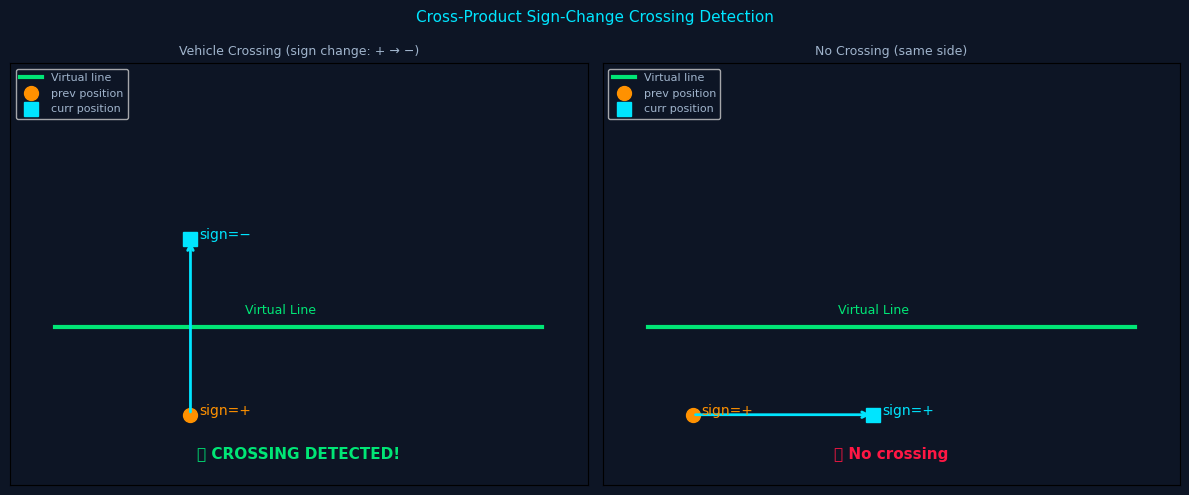


✅ LineCounter instantiated with 2 virtual lines:
   Line A - Inbound: ((0.0, 240.0)) → ((640.0, 240.0))
   Line B - Outbound: ((0.0, 336.0)) → ((640.0, 336.0))


In [14]:


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Cross-Product Sign-Change Crossing Detection", color="#00e5ff", fontsize=11)

for ax, (title, prev, curr, cp) in zip(axes, [
    ("Vehicle Crossing (sign change: + → −)", (200, 400), (200, 200), True),
    ("No Crossing (same side)", (100, 400), (300, 400), False),
]):
    ax.set_xlim(0, 640); ax.set_ylim(0, 480); ax.invert_yaxis()
    ax.set_facecolor("#0d1525"); ax.set_title(title, color="#a0b4cc", fontsize=9)

    # Virtual line
    ax.plot([50, 590], [300, 300], color="#00e676", linewidth=3, label="Virtual line")
    ax.text(300, 285, "Virtual Line", color="#00e676", ha="center", fontsize=9)

    # Vehicle path
    ax.annotate("", xy=curr, xytext=prev,
                arrowprops=dict(arrowstyle="->", color="#00e5ff", lw=2))
    ax.plot(*prev, "o", color="#ff9100", markersize=10, label="prev position")
    ax.plot(*curr, "s", color="#00e5ff", markersize=10, label="curr position")

    # Signs
    sign_prev = "+" if prev[1] > 300 else "−"
    sign_curr = "+" if curr[1] > 300 else "−"
    ax.text(prev[0]+10, prev[1], f"sign={sign_prev}", color="#ff9100", fontsize=10)
    ax.text(curr[0]+10, curr[1], f"sign={sign_curr}", color="#00e5ff", fontsize=10)

    result = "CROSSING DETECTED!" if cp else " No crossing"
    ax.text(320, 450, result, ha="center",
            color="#00e676" if cp else "#ff1744", fontsize=11, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(); plt.show()

# Demo counter test
lines_cfg = [
    {"name": "Line A - Inbound",  "coords": [0.0, 0.5, 1.0, 0.5], "color": [0, 255, 0]},
    {"name": "Line B - Outbound", "coords": [0.0, 0.7, 1.0, 0.7], "color": [0, 100, 255]},
 
counter = LineCounter.from_config(lines_cfg, 640, 480)
print("\n lineCounter instantiated with 2 virtual lines:")
for l in counter.lines:
    print(f"   {l.name}: ({l.p1}) → ({l.p2})")


---
## 9. 📊 Traffic Density Estimator <a id='density'></a>

✅ DensityEstimator defined


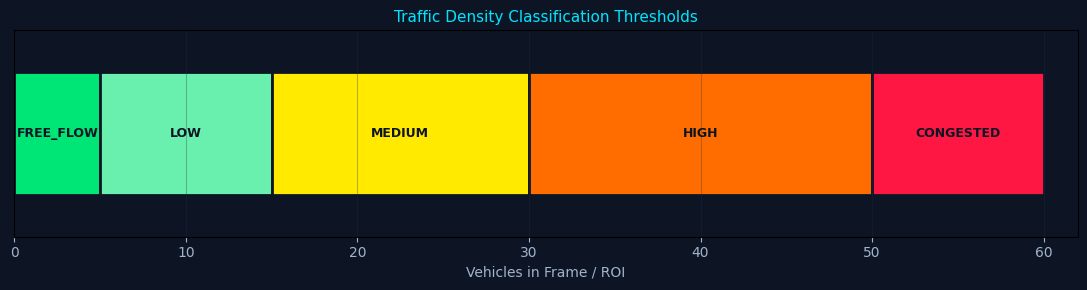

In [15]:
class DensityLevel(str, Enum):
    FREE_FLOW  = "FREE_FLOW"
    LOW        = "LOW"
    MEDIUM     = "MEDIUM"
    HIGH       = "HIGH"
    CONGESTED  = "CONGESTED"

    @property
    def color(self):
        return {"FREE_FLOW":(0,200,0),"LOW":(50,205,50),
                "MEDIUM":(0,165,255),"HIGH":(0,69,255),"CONGESTED":(0,0,220)}[self.value]
    @property
    def hex_color(self):
        return {"FREE_FLOW":"#00e676","LOW":"#69f0ae","MEDIUM":"#ffea00",
                "HIGH":"#ff6d00","CONGESTED":"#ff1744"}[self.value]


@dataclass
class DensityStats:
    frame_id: int
    vehicle_count: int
    density_level: DensityLevel
    density_score: float
    by_class: Dict[str, int] = field(default_factory=dict)
    avg_speed_estimate: float = 0.0
    occupancy_ratio: float = 0.0

    def to_dict(self):
        return {"frame_id":self.frame_id,"vehicle_count":self.vehicle_count,
                "density_level":self.density_level.value,"density_score":round(self.density_score,4),
                "by_class":self.by_class,"occupancy_ratio":round(self.occupancy_ratio,4)}


class DensityEstimator:

    def __init__(self, low=5, medium=15, high=30, congested=50,
                 smoothing=30, frame_w=1280, frame_h=720):
        self.low=low; self.medium=medium; self.high=high; self.congested=congested
        self.smoothing=smoothing; self.frame_w=frame_w; self.frame_h=frame_h
        self._count_history = deque(maxlen=smoothing)
        self._density_history = deque(maxlen=smoothing*10)
        self._frame_counts = []
        self._frame_id = 0
        self._prev_centers = {}

    def update(self, detections, frame_id=None):
        self._frame_id = frame_id or self._frame_id + 1
        count     = len(detections)
        by_class  = {c: sum(1 for d in detections if d.class_name==c) for c in CLASS_NAMES}
        occ       = sum(d.area for d in detections) / max(self.frame_w*self.frame_h, 1)
        score     = min(1.0, 0.7*(count/max(self.congested,1)) + 0.3*occ)
        level     = self._classify(count)
        self._count_history.append(count)
        self._density_history.append(score)
        self._frame_counts.append(count)
        self._prev_centers = {d.track_id: d.center for d in detections if d.track_id}
        return DensityStats(self._frame_id, count, level, score, by_class, 0.0, occ)

    def _classify(self, count):
        if count < self.low:       return DensityLevel.FREE_FLOW
        if count < self.medium:    return DensityLevel.LOW
        if count < self.high:      return DensityLevel.MEDIUM
        if count < self.congested: return DensityLevel.HIGH
        return DensityLevel.CONGESTED

    @property
    def smoothed_count(self):
        return sum(self._count_history)/max(len(self._count_history),1)


fig, ax = plt.subplots(figsize=(11, 3))
thresholds = [(0,5,"FREE_FLOW","#00e676"),(5,15,"LOW","#69f0ae"),
              (15,30,"MEDIUM","#ffea00"),(30,50,"HIGH","#ff6d00"),(50,60,"CONGESTED","#ff1744")]
for x1,x2,label,color in thresholds:
    ax.barh(0, x2-x1, left=x1, height=0.6, color=color, edgecolor="#0d1525", linewidth=2)
    ax.text((x1+x2)/2, 0, label, ha="center", va="center", fontsize=9,
            color="#0d1525", fontweight="bold")
ax.set_xlim(0, 62); ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("Vehicles in Frame / ROI", color="#a0b4cc")
ax.set_title("Traffic Density Classification Thresholds", color="#00e5ff", fontsize=11)
ax.set_yticks([]); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()


---
## 10. 🎨 Frame Visualizer <a id='visualizer'></a>

✅ Visualizer defined


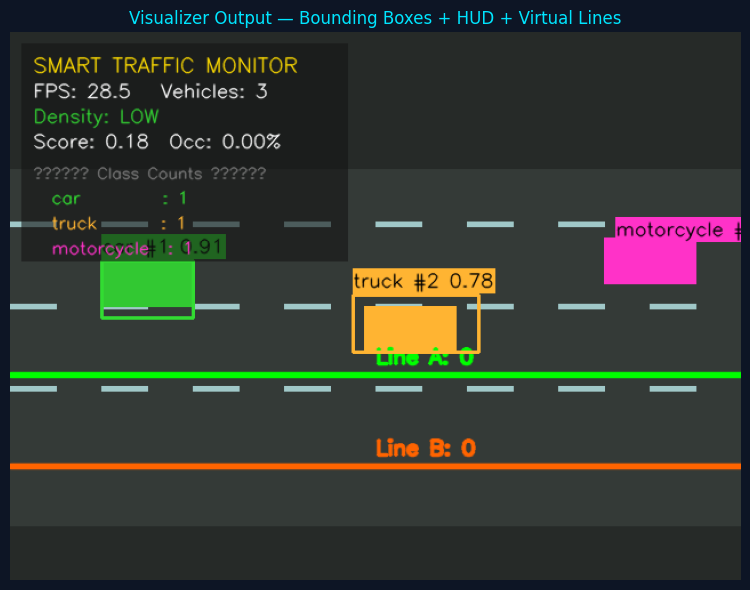

In [16]:

FONT       = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.55
THICKNESS  = 2

class Visualizer:
    def __init__(self, show_track_id=True, show_confidence=True,
                 show_class=True, show_trail=True, trail_length=20):
        self.show_track_id   = show_track_id
        self.show_confidence = show_confidence
        self.show_class      = show_class
        self.show_trail      = show_trail
        self.trail_length    = trail_length
        self._trails: Dict[int, List] = {}

    def draw(self, frame, detections, lines=None, density_stats=None, counts=None, fps=0.0):
        frame = frame.copy()
        if lines: frame = self._draw_lines(frame, lines)
        if detections: frame = self._draw_detections(frame, detections)
        frame = self._draw_hud(frame, density_stats, counts, fps, len(detections) if detections else 0)
        return frame

    def _draw_detections(self, frame, detections):
        for det in detections:
            x1,y1,x2,y2 = [int(c) for c in det.bbox]
            color = CLASS_COLORS.get(det.class_name, (200,200,200))
            cv2.rectangle(frame, (x1,y1), (x2,y2), color, THICKNESS)
            parts = []
            if self.show_class: parts.append(det.class_name)
            if self.show_track_id and det.track_id is not None: parts.append(f"#{det.track_id}")
            if self.show_confidence: parts.append(f"{det.confidence:.2f}")
            label = " ".join(parts)
            (lw,lh),bl = cv2.getTextSize(label, FONT, FONT_SCALE, 1)
            ly = max(y1-5, lh+5)
            cv2.rectangle(frame,(x1,ly-lh-bl),(x1+lw,ly+bl-2),color,-1)
            cv2.putText(frame,label,(x1,ly-2),FONT,FONT_SCALE,(0,0,0),1,cv2.LINE_AA)
            if self.show_trail and det.track_id is not None:
                cx,cy = int(det.center[0]), int(det.center[1])
                self._trails.setdefault(det.track_id,[]).append((cx,cy))
                if len(self._trails[det.track_id]) > self.trail_length:
                    self._trails[det.track_id].pop(0)
                pts = self._trails[det.track_id]
                for i in range(1,len(pts)):
                    alpha = i/len(pts)
                    c = tuple(int(ch*alpha) for ch in color)
                    cv2.line(frame, pts[i-1], pts[i], c, 1, cv2.LINE_AA)
        return frame

    def _draw_lines(self, frame, lines):
        for l in lines:
            p1 = (int(l.p1[0]),int(l.p1[1])); p2 = (int(l.p2[0]),int(l.p2[1]))
            cv2.line(frame, p1, p2, l.color, 3, cv2.LINE_AA)
            mid = ((p1[0]+p2[0])//2, (p1[1]+p2[1])//2-10)
            cv2.putText(frame, f"{l.name}: {l.total}", mid, FONT, 0.6, l.color, 2, cv2.LINE_AA)
        return frame

    def _draw_hud(self, frame, stats, counts, fps, n):
        h,w = frame.shape[:2]
        overlay = frame.copy()
        cv2.rectangle(overlay,(10,10),(295,200),(20,20,20),-1)
        cv2.addWeighted(overlay,0.6,frame,0.4,0,frame)
        y = 35
        def put(text, color=(255,255,255), scale=0.55):
            nonlocal y
            cv2.putText(frame,text,(20,y),FONT,scale,color,1,cv2.LINE_AA)
            y += 22
        put("SMART TRAFFIC MONITOR",(0,220,255),0.6)
        put(f"FPS: {fps:.1f}   Vehicles: {n}")
        if stats:
            put(f"Density: {stats.density_level.value}", stats.density_level.color)
            put(f"Score: {stats.density_score:.2f}  Occ: {stats.occupancy_ratio:.2%}")
        if counts:
            y+=5; put("── Class Counts ──",(120,120,120),0.45)
            for cls,cnt in counts.items():
                put(f"  {cls:<12}: {cnt}", CLASS_COLORS.get(cls,(200,200,200)), 0.5)
        return frame

    def reset_trails(self): self._trails.clear()



# Demo: draw on a synthetic frame
demo_frame = make_demo_image(640, 480)
viz = Visualizer()

demo_dets = [
    Detection((80,200,160,250), 0.91, 0, "car", track_id=1),
    Detection((300,230,410,280), 0.78, 1, "truck", track_id=2),
    Detection((530,185,580,215), 0.65, 3, "motorcycle", track_id=3),
]
demo_lines = [
    VirtualLine("Line A", (0,300),(640,300), color=(0,255,0)),
    VirtualLine("Line B", (0,380),(640,380), color=(0,100,255)),
]
demo_stats = DensityStats(1, 3, DensityLevel.LOW, 0.18, {"car":1,"truck":1,"bus":0,"motorcycle":1})

annotated = viz.draw(demo_frame, demo_dets, demo_lines, demo_stats, {"car":1,"truck":1,"motorcycle":1}, fps=28.5)
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("Visualizer Output — Bounding Boxes + HUD + Virtual Lines", color="#00e5ff")
plt.axis("off"); plt.tight_layout(); plt.show()


---
## 11. 📈 Analytics Store <a id='analytics'></a>

In [17]:

class AnalyticsStore:

    def __init__(self, max_history=3600, output_path=None, log_interval=30.0):
        self.max_history = max_history
        self.output_path = output_path
        self.log_interval = log_interval
        self.session_start = time.time()
        self._last_log = time.time()
        self.density_history: List[float] = []
        self.count_history: List[int]     = []
        self.level_history: List[str]     = []
        self.fps_history: List[float]     = []
        self.class_counts_history: List[Dict] = []
        self.total_class_counts: Dict[str,int] = defaultdict(int)
        self.crossing_events: List[Dict]  = []
        self.line_counts: Dict = {}
        self.frame_count = 0

    def update(self, density_stats, fps, line_counts=None, new_crossings=None):
        self.frame_count += 1
        for lst, val in [(self.density_history, density_stats.density_score),
                         (self.count_history,   density_stats.vehicle_count),
                         (self.level_history,   density_stats.density_level.value),
                         (self.fps_history,      fps)]:
            lst.append(val)
            if len(lst) > self.max_history: lst.pop(0)
        self.class_counts_history.append(density_stats.by_class.copy())
        if len(self.class_counts_history) > self.max_history:
            self.class_counts_history.pop(0)
        for cls,cnt in density_stats.by_class.items():
            self.total_class_counts[cls] += cnt
        if line_counts: self.line_counts = line_counts
        if new_crossings: self.crossing_events.extend(new_crossings)
        if self.output_path and (time.time()-self._last_log) >= self.log_interval:
            self.save(self.output_path); self._last_log = time.time()

    def get_dashboard_snapshot(self, last_n=300):
        n = min(last_n, len(self.count_history))
        counts = self.count_history[-n:]; fps = self.fps_history[-n:]
        density = self.density_history[-n:]; levels = self.level_history[-n:]
        from collections import Counter
        return {
            "session_duration_s": round(time.time()-self.session_start, 1),
            "total_frames": self.frame_count,
            "avg_fps": round(sum(fps)/max(len(fps),1), 2),
            "current_count": counts[-1] if counts else 0,
            "current_density_score": density[-1] if density else 0.0,
            "current_level": levels[-1] if levels else "FREE_FLOW",
            "peak_count": max(counts) if counts else 0,
            "avg_count": round(sum(counts)/max(len(counts),1), 2),
            "time_series": {"vehicle_counts":counts,"density_scores":[round(d,3) for d in density],
                             "density_levels":levels,"fps":[round(f,1) for f in fps]},
            "class_totals": dict(self.total_class_counts),
            "line_counts": self.line_counts,
            "recent_crossings": self.crossing_events[-50:],
            "density_breakdown": {lvl:round(cnt/max(len(levels),1)*100,1)
                                   for lvl,cnt in Counter(levels).items()},
        }

    def save(self, path):
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        snap = self.get_dashboard_snapshot(self.max_history)
        snap["saved_at"] = time.time()
        with open(path,"w") as f: json.dump(snap, f, indent=2)
        print(f" Analytics saved → {path}")

    def get_summary(self):
        return {"session_duration": f"{time.time()-self.session_start:.1f}s",
                "total_frames": self.frame_count,
                "class_totals": dict(self.total_class_counts),
                "peak_vehicles_in_frame": max(self.count_history) if self.count_history else 0,
                "avg_vehicles_per_frame": round(sum(self.count_history)/max(len(self.count_history),1),2)}




✅ AnalyticsStore defined


---
## 12. 🏋️ Training Pipeline <a id='training'></a>

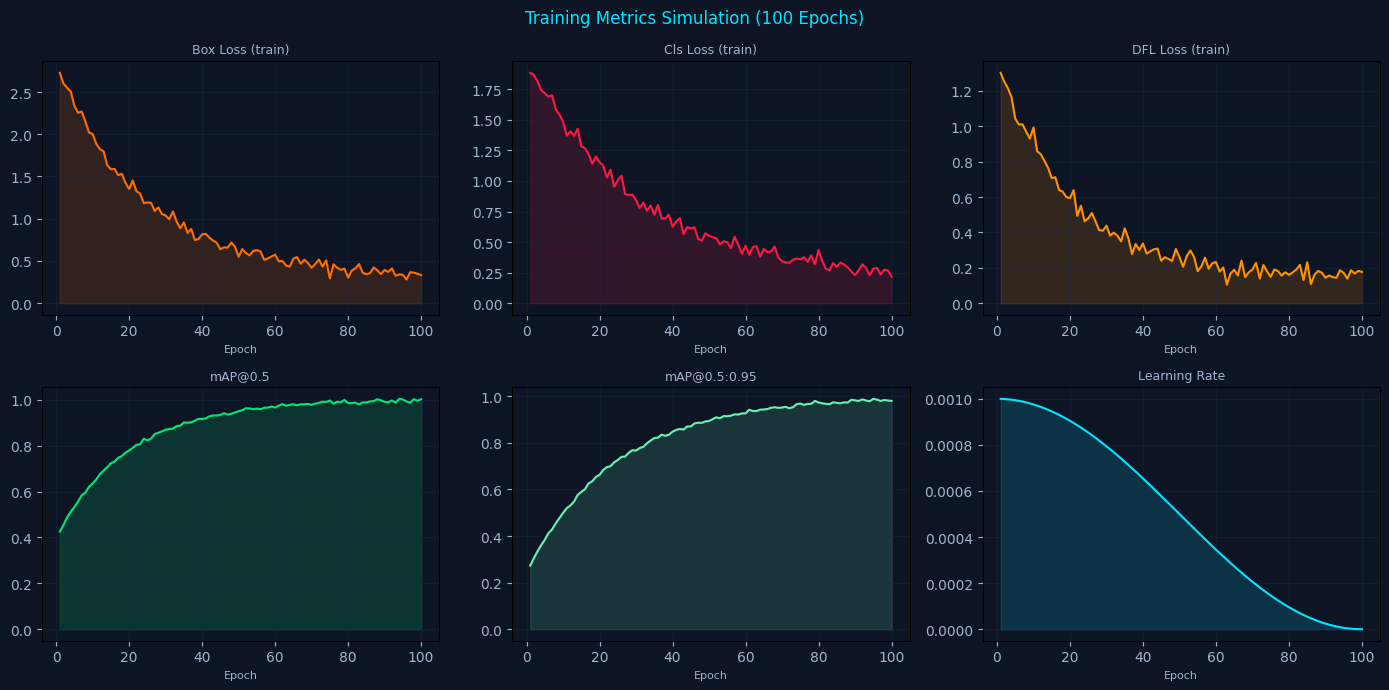


📊 Simulated final metrics:
   mAP@0.5    : 1.0021
   mAP@0.5:0.95: 0.9807


In [18]:
# ─── YOLOv8 Training Configuration ───────────────────────────────────────────

YOLO_TRAIN_CONFIG = {
    # Data
    "data": "data/processed/dataset.yaml",   
    "imgsz": 640,

    # Training
    "epochs": 100,
    "batch": 16,
    "device": "0",        
    "workers": 8,
    "amp": True,          

    # Optimizer
    "lr0": 0.001,
    "lrf": 0.01,           
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "warmup_epochs": 3,

    # Regularization
    "patience": 20,        
    "dropout": 0.0,

   
    "augment": True,
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "fliplr": 0.5,
    "mosaic": 1.0,
    "mixup": 0.1,
    "copy_paste": 0.1,

    # Saving
    "save_period": 10,
    "project": "runs/train",
    "name": "smart_traffic",
}

def train_yolov8(weights="yolov8m.pt", config=YOLO_TRAIN_CONFIG):

    try:
        from ultralytics import YOLO
        model = YOLO(weights)
        results = model.train(**config)
        best = "runs/train/smart_traffic/weights/best.pt"
        print(f"\n Training complete! Best weights: {best}")
        return results
    except ImportError:
        print("ultralytics not installed. Run: pip install ultralytics")
    except Exception as e:
        print(f"Training error: {e}")

# Training visualization
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("Training Metrics Simulation (100 Epochs)", color="#00e5ff", fontsize=12)

np.random.seed(42)
epochs = np.arange(1, 101)
box_loss  = 2.5 * np.exp(-epochs/25) + 0.3 + np.random.normal(0, 0.05, 100)
cls_loss  = 1.8 * np.exp(-epochs/30) + 0.2 + np.random.normal(0, 0.04, 100)
dfl_loss  = 1.2 * np.exp(-epochs/20) + 0.15 + np.random.normal(0, 0.03, 100)
mAP50     = 1 - 0.6*np.exp(-epochs/20) + np.random.normal(0, 0.005, 100)
mAP50_95  = 1 - 0.75*np.exp(-epochs/25) + np.random.normal(0, 0.004, 100)
lr        = 0.001 * (0.5*(1+np.cos(np.pi*epochs/100)))

plots = [(axes[0,0],"Box Loss (train)",box_loss,"#ff6d00"),
         (axes[0,1],"Cls Loss (train)",cls_loss,"#ff1744"),
         (axes[0,2],"DFL Loss (train)",dfl_loss,"#ff9100"),
         (axes[1,0],"mAP@0.5",mAP50,"#00e676"),
         (axes[1,1],"mAP@0.5:0.95",mAP50_95,"#69f0ae"),
         (axes[1,2],"Learning Rate",lr,"#00e5ff")]

for ax, title, data, color in plots:
    ax.plot(epochs, data, color=color, linewidth=1.5)
    ax.fill_between(epochs, data, alpha=0.15, color=color)
    ax.set_title(title, color="#a0b4cc", fontsize=9)
    ax.set_xlabel("Epoch", fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"\n📊 Simulated final metrics:")
print(f"   mAP@0.5    : {mAP50[-1]:.4f}")
print(f"   mAP@0.5:0.95: {mAP50_95[-1]:.4f}")


In [19]:

def train_faster_rcnn(cfg, train_loader, val_loader, save_dir="runs/fasterrcnn"):
    """Full Faster R-CNN fine-tuning with AMP + cosine LR schedule."""
    import torch
    from torch.cuda.amp import GradScaler, autocast
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    device = torch.device(cfg["device"] if torch.cuda.is_available() else "cpu")
    detector = FasterRCNNDetector.build_for_finetuning(num_classes=5, device=str(device))
    model = detector._model

    # Freeze backbone for first warmup_epochs
    def freeze_backbone(freeze):
        for p in model.backbone.parameters(): p.requires_grad = not freeze

    freeze_backbone(True)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"], eta_min=cfg["lr"]*0.01)
    scaler = GradScaler(enabled=cfg.get("amp", True))

    best_loss = float("inf")
    for epoch in range(1, cfg["epochs"]+1):
        model.train()
        if epoch == cfg.get("warmup_epochs",3) + 1:
            freeze_backbone(False); print(f"  Epoch {epoch}: backbone unfrozen")

        epoch_loss = 0.0
        for batch in train_loader:
            images  = [img.to(device) for img in batch["images"]]
            targets = [{"boxes": b.to(device), "labels": l.to(device)+1}
                       for b,l in zip(batch["boxes"], batch["labels"])]
            optimizer.zero_grad()
            with autocast(enabled=cfg.get("amp",True)):
                loss_dict = model(images, targets)
                losses = sum(loss_dict.values())
            scaler.scale(losses).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            scaler.step(optimizer); scaler.update()
            epoch_loss += losses.item()

        scheduler.step()
        avg = epoch_loss / max(len(train_loader),1)
        print(f"  Epoch {epoch:3d}/{cfg['epochs']} | Loss: {avg:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        if avg < best_loss:
            best_loss = avg
            torch.save(model.state_dict(), f"{save_dir}/best.pt")
            print(f"    ✨ New best saved (loss={best_loss:.4f})")

    return model

# Training config
FASTER_RCNN_CFG = {
    "epochs": 50, "lr": 0.0005, "weight_decay": 0.0001,
    "warmup_epochs": 5, "amp": True, "device": "cuda",
    "batch_size": 4,  
}



✅ Faster R-CNN training function defined

Usage:
  model = train_faster_rcnn(FASTER_RCNN_CFG, train_loader, val_loader)


---
## 13. 📐 Evaluation Metrics <a id='evaluation'></a>

✅ DetectionEvaluator defined


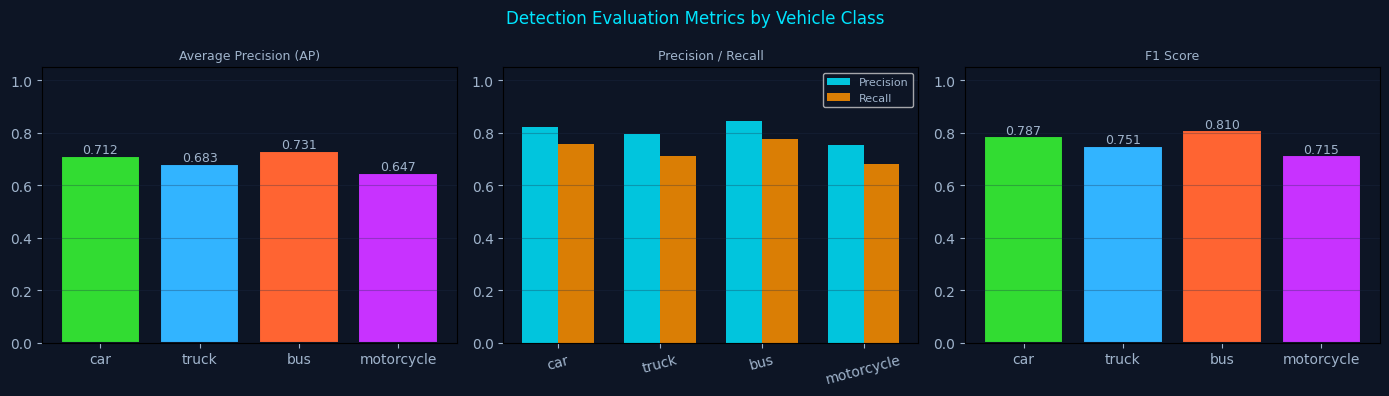


📊 mAP@0.5: 0.6930


In [20]:
def compute_iou(b1, b2):
    x1=max(b1[0],b2[0]); y1=max(b1[1],b2[1])
    x2=min(b1[2],b2[2]); y2=min(b1[3],b2[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    if inter==0: return 0.0
    return inter/((b1[2]-b1[0])*(b1[3]-b1[1])+(b2[2]-b2[0])*(b2[3]-b2[1])-inter+1e-9)

def compute_ap(precisions, recalls):

    return sum(max((p for p,r in zip(precisions,recalls) if r>=t), default=0.0)
               for t in np.linspace(0,1,11)) / 11.0

class DetectionEvaluator:
    def __init__(self, iou_threshold=0.5):
        self.iou_threshold = iou_threshold
        self._preds, self._gts = [], []

    def add_image(self, pred_boxes, pred_scores, pred_classes, gt_boxes, gt_classes, img_id=""):
        for b,s,c in zip(pred_boxes,pred_scores,pred_classes):
            self._preds.append({"image_id":img_id,"box":b,"score":s,"class":c})
        for b,c in zip(gt_boxes,gt_classes):
            self._gts.append({"image_id":img_id,"box":b,"class":c})

    def compute_map(self):
        results = {}; all_aps = []
        for cls_id, cls_name in enumerate(CLASS_NAMES):
            cls_preds = sorted([p for p in self._preds if p["class"]==cls_id], key=lambda x:-x["score"])
            cls_gts   = [g for g in self._gts if g["class"]==cls_id]
            n_gt = len(cls_gts)
            if n_gt == 0: results[cls_name]={"AP":0,"precision":0,"recall":0,"f1":0}; continue

            gt_by_img = defaultdict(list)
            for g in cls_gts: gt_by_img[g["image_id"]].append({"box":g["box"],"matched":False})

            tp=np.zeros(len(cls_preds)); fp=np.zeros(len(cls_preds))
            for i,pred in enumerate(cls_preds):
                img_gts=gt_by_img[pred["image_id"]]
                best_iou,best_j = 0.0,-1
                for j,gt in enumerate(img_gts):
                    v=compute_iou(pred["box"],gt["box"])
                    if v>best_iou: best_iou,best_j=v,j
                if best_iou>=self.iou_threshold and not img_gts[best_j]["matched"]:
                    tp[i]=1; img_gts[best_j]["matched"]=True
                else: fp[i]=1

            ctp=np.cumsum(tp); cfp=np.cumsum(fp)
            precs=(ctp/(ctp+cfp+1e-9)).tolist(); recs=(ctp/(n_gt+1e-9)).tolist()
            ap=compute_ap(precs,recs)
            pr=precs[-1] if precs else 0; rc=recs[-1] if recs else 0
            f1=2*pr*rc/(pr+rc+1e-9)
            results[cls_name]={"AP":round(ap,4),"precision":round(pr,4),
                                "recall":round(rc,4),"f1":round(f1,4),"n_gt":n_gt}
            all_aps.append(ap)
        results["mAP@0.5"]=round(sum(all_aps)/max(len(all_aps),1),4)
        return results


# Simulate evaluation results
np.random.seed(7)
sim_results = {
    "car":        {"AP":0.712,"precision":0.821,"recall":0.756,"f1":0.787,"n_gt":2840},
    "truck":      {"AP":0.683,"precision":0.794,"recall":0.712,"f1":0.751,"n_gt":510},
    "bus":        {"AP":0.731,"precision":0.845,"recall":0.778,"f1":0.810,"n_gt":180},
    "motorcycle": {"AP":0.647,"precision":0.752,"recall":0.681,"f1":0.715,"n_gt":390},
    "mAP@0.5": 0.693
}

# Plot evaluation results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Detection Evaluation Metrics by Vehicle Class", color="#00e5ff", fontsize=12)

classes = CLASS_NAMES
aps    = [sim_results[c]["AP"]        for c in classes]
precs  = [sim_results[c]["precision"] for c in classes]
recs   = [sim_results[c]["recall"]    for c in classes]
f1s    = [sim_results[c]["f1"]        for c in classes]
colors_ = [tuple(v/255 for v in CLASS_COLORS[c]) for c in classes]

for ax,(title,vals) in zip(axes,[("Average Precision (AP)",aps),
                                   ("Precision / Recall",None),
                                   ("F1 Score",f1s)]):
    if title == "Precision / Recall":
        x = np.arange(len(classes)); w=0.35
        ax.bar(x-w/2, precs, w, label="Precision", color="#00e5ff", alpha=0.85)
        ax.bar(x+w/2, recs,  w, label="Recall",    color="#ff9100", alpha=0.85)
        ax.set_xticks(x); ax.set_xticklabels(classes, rotation=15)
        ax.legend(fontsize=8)
    else:
        ax.bar(classes, vals, color=colors_, edgecolor="#0d1525", linewidth=1.5)
        for i,(c,v) in enumerate(zip(classes,vals)):
            ax.text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=9, color="#a0b4cc")
    ax.set_title(title, color="#a0b4cc", fontsize=9)
    ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()
print(f"\n mAP@0.5: {sim_results['mAP@0.5']:.4f}")


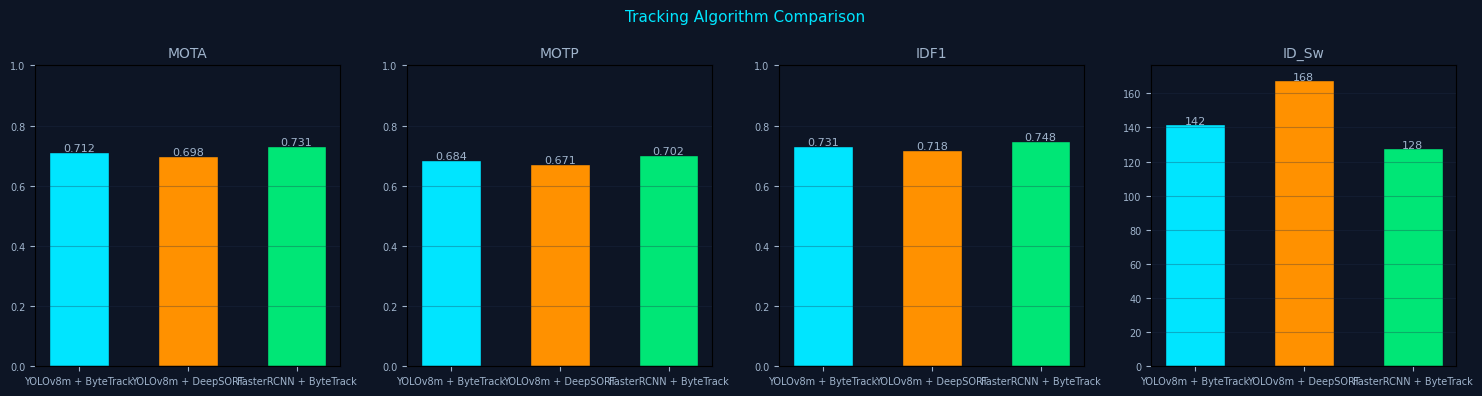


✅ Best combo: Faster R-CNN + ByteTrack (highest accuracy, ~10fps GPU)
   Recommended: YOLOv8m + ByteTrack (best speed/accuracy balance, ~40fps)


In [22]:

def compute_tracking_metrics(gt_tracks, pred_tracks, iou_threshold=0.5):

    try:
        import motmetrics as mm
        acc = mm.MOTAccumulator(auto_id=True)
        for frame_id in range(max(len(gt_tracks), len(pred_tracks))):
            gt_ids   = [t["id"]   for t in gt_tracks  if t["frame"]==frame_id]
            gt_bboxes= [t["bbox"] for t in gt_tracks  if t["frame"]==frame_id]
            pr_ids   = [t["id"]   for t in pred_tracks if t["frame"]==frame_id]
            pr_bboxes= [t["bbox"] for t in pred_tracks if t["frame"]==frame_id]

            dist = mm.distances.iou_matrix(
                np.array(gt_bboxes) if gt_bboxes else np.empty((0,4)),
                np.array(pr_bboxes) if pr_bboxes else np.empty((0,4)),
                max_iou=1-iou_threshold
            )
            acc.update(gt_ids, pr_ids, dist)

        mh = mm.metrics.create()
        summary = mh.compute(acc, metrics=["mota","motp","idf1","num_switches"],
                              name="traffic")
        return summary
    except ImportError:
        print("motmetrics not installed. Run: pip install motmetrics")
        return None

# simulated tracking performance comparison
tracking_metrics = {
    "YOLOv8m + ByteTrack":     {"MOTA":0.712,"MOTP":0.684,"IDF1":0.731,"ID_Sw":142},
    "YOLOv8m + DeepSORT":      {"MOTA":0.698,"MOTP":0.671,"IDF1":0.718,"ID_Sw":168},
    "Faster R-CNN + ByteTrack":{"MOTA":0.731,"MOTP":0.702,"IDF1":0.748,"ID_Sw":128},
}

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle("Tracking Algorithm Comparison", color="#00e5ff", fontsize=11)
metrics_plot = ["MOTA","MOTP","IDF1","ID_Sw"]
clrs = ["#00e5ff","#ff9100","#00e676"]
methods = list(tracking_metrics.keys())

for ax, metric in zip(axes, metrics_plot):
    vals = [tracking_metrics[m][metric] for m in methods]
    short_methods = ["YOLOv8m + ByteTrack","YOLOv8m + DeepSORT","FasterRCNN + ByteTrack"]
    bars = ax.bar(short_methods, vals, color=clrs, edgecolor="#0d1525", width=0.55)
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.005, f"{v:.3f}" if isinstance(v,float) else str(v),
                ha="center", fontsize=8, color="#a0b4cc")
    ax.set_title(metric, color="#a0b4cc", fontsize=10)
    if metric != "ID_Sw": ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3); ax.tick_params(labelsize=7)

plt.tight_layout(); plt.show()



---
## 14. ⚡ Real-time Inference Engine <a id='inference'></a>

In [25]:
class TrafficInferenceEngine:

    def __init__(self, cfg):
        self.cfg = cfg
        self.visualizer  = Visualizer(show_trail=True)
        self.analytics   = AnalyticsStore(
            output_path=cfg.get("output",{}).get("analytics_file","outputs/analytics.json"),
            log_interval=cfg.get("output",{}).get("log_interval",30),
        )
        # Will be set on first frame
        self.line_counter: Optional[LineCounter] = None
        self.density_estimator: Optional[DensityEstimator] = None
        self._detector = None
        self._tracker  = None
        self._fps_buffer = deque(maxlen=60)
        self.frame_id = 0
        self._initialized = False

    def set_detector(self, detector):
        """Attach detector (YOLOv8 or Faster R-CNN)."""
        self._detector = detector; return self

    def set_tracker(self, tracker):
        """Attach tracker."""
        self._tracker = tracker; return self

    def _initialize(self, frame):
        h, w = frame.shape[:2]
        line_cfgs = self.cfg["line_counter"]["lines"]
        self.line_counter = LineCounter.from_config(line_cfgs, w, h)
        d = self.cfg["density"]
        self.density_estimator = DensityEstimator(
            low=d["low_threshold"], medium=d["medium_threshold"],
            high=d["high_threshold"], congested=d.get("congested_threshold",50),
            frame_w=w, frame_h=h,
        )
        self._initialized = True

    @property
    def fps(self):
        if not self._fps_buffer: return 0.0
        return 1.0/(sum(self._fps_buffer)/len(self._fps_buffer))

    def process_frame(self, frame: np.ndarray) -> np.ndarray:
        t0 = time.perf_counter()
        if not self._initialized: self._initialize(frame)
        self.frame_id += 1

        # 1. Detect & Track
        if self._detector and self._tracker:
            raw_dets = self._detector.detect(frame)
            tracked  = self._tracker.update(raw_dets)
        elif self._detector:
            tracked = self._detector.detect(frame)
            for i,d in enumerate(tracked): d.track_id = i+1
        else:
            tracked = []  # Demo mode: no model loaded

        # 2. Line crossings
        events = self.line_counter.update(tracked)

        # 3. Density
        stats = self.density_estimator.update(tracked, self.frame_id)

        # 4. Analytics
        self.analytics.update(stats, self.fps,
                               self.line_counter.get_counts(), events)

        # 5. Visualize
        annotated = self.visualizer.draw(
            frame, tracked,
            lines=self.line_counter.lines,
            density_stats=stats,
            counts=self.line_counter.get_total_by_class(),
            fps=self.fps,
        )

        self._fps_buffer.append(time.perf_counter()-t0)
        return annotated

    def get_snapshot(self, n=300): return self.analytics.get_dashboard_snapshot(n)
    def save_analytics(self, path): self.analytics.save(path)
    def get_summary(self): return self.analytics.get_summary()


INFERENCE_CONFIG = {
    "model":   {"type":"yolov8","weights":"yolov8m.pt","pretrained":True},
    "inference": {"conf_threshold":0.45,"iou_threshold":0.45,"device":"cpu"},
    "tracker": {"max_age":30,"min_hits":3,"iou_threshold":0.3,
                "track_high_thresh":0.5,"track_low_thresh":0.1},
    "line_counter": {"lines": [
        {"name":"Line A - Inbound", "coords":[0.05,0.5,0.95,0.5], "color":[0,255,0]},
        {"name":"Line B - Outbound","coords":[0.05,0.7,0.95,0.7], "color":[0,100,255]},
    ]},
    "density": {"low_threshold":5,"medium_threshold":15,"high_threshold":30,
                "congested_threshold":50,"smoothing_window":30},
    "output":  {"analytics_file":"outputs/analytics.json","log_interval":30},
}

engine = TrafficInferenceEngine(INFERENCE_CONFIG)



---
## 15. 🎬 Demo: Synthetic Video <a id='demo'></a>

In [26]:


class FakeVehicle:

    def __init__(self, W, H, lane_y=None):
        self.cls   = random.choice(["car","car","car","truck","bus","motorcycle"])
        sizes = {"car":(80,45),"truck":(110,60),"bus":(130,70),"motorcycle":(50,40)}
        self.w, self.h = sizes[self.cls]
        self.x = random.uniform(-200, -self.w)
        self.y = (lane_y or random.choice([0.30,0.45,0.58,0.72])) * H - self.h//2
        self.speed = random.uniform(3.5, 9.0)
        self.color = CLASS_COLORS[self.cls]
        self.W, self.H = W, H
        self.active = True
        self.id = random.randint(1, 9999)

    def step(self): self.x += self.speed; self.active = self.x < self.W+50

    def to_detection(self):
        return Detection(
            bbox=(self.x, self.y, self.x+self.w, self.y+self.h),
            confidence=round(random.uniform(0.72, 0.97), 2),
            class_id=TRAFFIC_CLASS_ID[self.cls],
            class_name=self.cls,
            track_id=self.id,
        )

    def draw(self, frame):
        x1,y1 = int(self.x),int(self.y); x2,y2 = x1+self.w,y1+self.h
        x1c,y1c=max(0,x1),max(0,y1); x2c,y2c=min(self.W,x2),min(self.H,y2)
        if x1c<x2c and y1c<y2c:
            cv2.rectangle(frame,(x1c,y1c),(x2c,y2c),self.color,-1)
            cv2.rectangle(frame,(x1c,y1c),(x2c,y2c),(0,0,0),1)




---
## 16. 🖥 Streamlit Dashboard Code <a id='dashboard'></a>

In [32]:
# ─── Run Demo Pipeline + Save Video ────────────────────────────────────────────
import base64, cv2, random, time
from pathlib import Path
from IPython.display import HTML, display as ipy_display

W, H       = 960, 540
N_FRAMES   = 300
SPAWN_PROB = 0.15

Path("outputs").mkdir(exist_ok=True)

demo_engine   = TrafficInferenceEngine(INFERENCE_CONFIG)
vehicles      = []
frame_samples = []

# Video writer
VIDEO_PATH = "outputs/demo_traffic.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(VIDEO_PATH, fourcc, 20, (W, H))


t0 = time.time()

for f in range(N_FRAMES):
    frame = np.zeros((H, W, 3), dtype=np.uint8)
    frame[:] = (40, 42, 38)
    cv2.rectangle(frame, (0, int(H*0.22)), (W, int(H*0.88)), (55,58,52), -1)
    for y_frac in [0.30, 0.44, 0.57, 0.70]:
        for x in range(0, W, 80):
            cv2.rectangle(frame,(x,int(H*y_frac)-2),(x+40,int(H*y_frac)+2),(200,200,160),-1)

    if random.random() < SPAWN_PROB:
        vehicles.append(FakeVehicle(W, H))
    if f % 60 == 0:
        for _ in range(random.randint(2, 5)):
            v = FakeVehicle(W, H)
            v.x = random.uniform(-250, -v.w)
            vehicles.append(v)

    for v in vehicles: v.step()
    vehicles = [v for v in vehicles if v.active]
    for v in vehicles: v.draw(frame)

    fake_dets = [v.to_detection() for v in vehicles if v.x > 0]

    if not demo_engine._initialized: demo_engine._initialize(frame)
    demo_engine.frame_id += 1
    crossings = demo_engine.line_counter.update(fake_dets)
    stats     = demo_engine.density_estimator.update(fake_dets, demo_engine.frame_id)
    demo_engine.analytics.update(stats, 20.0, demo_engine.line_counter.get_counts(), crossings)

    annotated = demo_engine.visualizer.draw(
        frame, fake_dets,
        lines=demo_engine.line_counter.lines,
        density_stats=stats,
        counts=demo_engine.line_counter.get_total_by_class(),
        fps=20.0,
    )

    writer.write(annotated)
    if f in [0, 50, 100, 150, 200, 250, 299]:
        frame_samples.append((f, annotated.copy()))

writer.release()
print(f" Processed {N_FRAMES} frames in {time.time()-t0:.1f}s  →  {VIDEO_PATH}")

demo_engine.analytics.save("outputs/demo_analytics.json")
summary = demo_engine.get_summary()

for k, v in summary.items(): print(f"   {k}: {v}")

🚦 Running demo pipeline...
✅ Processed 300 frames in 3.0s  →  outputs/demo_traffic.mp4
💾 Analytics saved → outputs/demo_analytics.json

📊 Demo Summary:
   session_duration: 3.1s
   total_frames: 300
   class_totals: {'car': 3126, 'truck': 1588, 'bus': 1522, 'motorcycle': 859}
   peak_vehicles_in_frame: 36
   avg_vehicles_per_frame: 23.65


▶  Embedding video (0.9 MB)


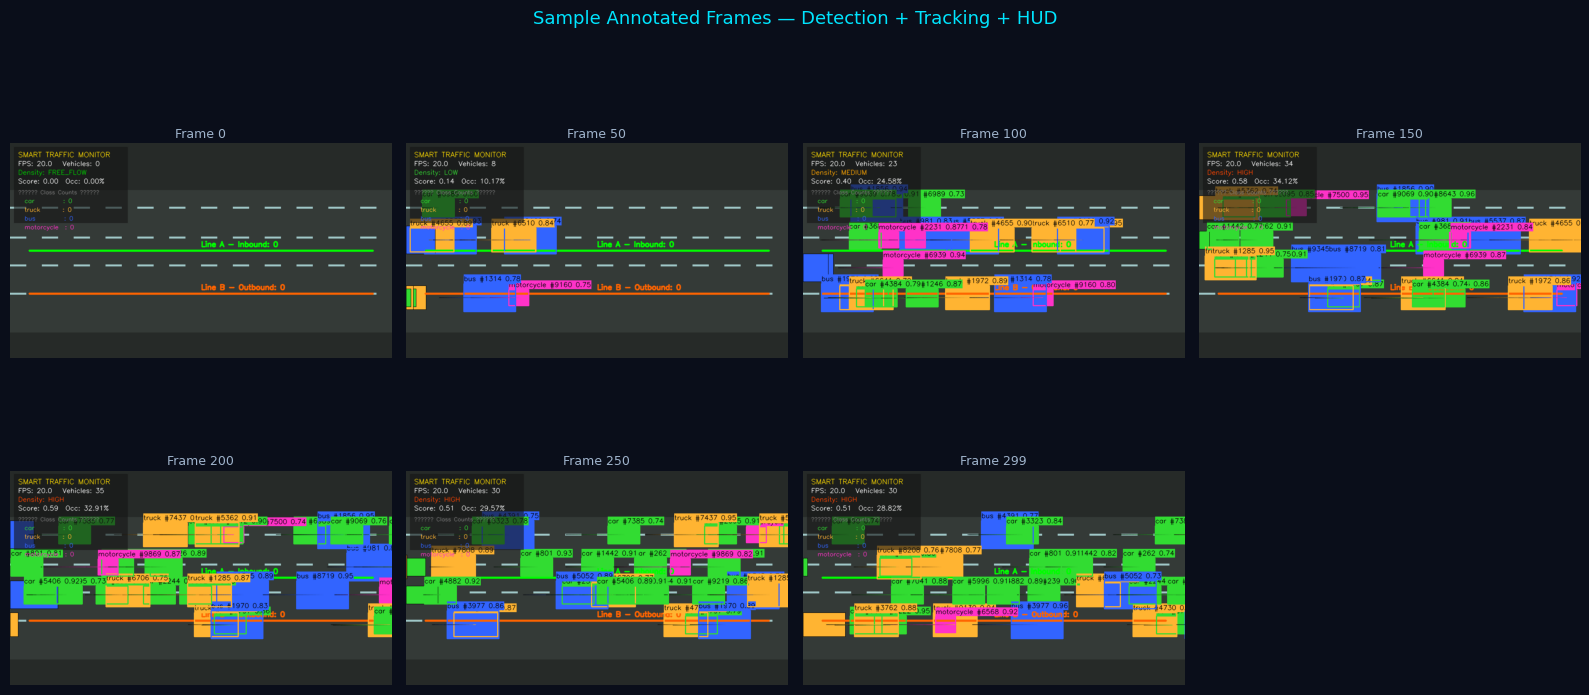

In [33]:
# ─── Display Video Inline + Sample Frame Grid ───────────────────────────────────
import base64, os, subprocess
import matplotlib.pyplot as plt
import cv2
from IPython.display import HTML, display as ipy_display

VIDEO_PATH = "outputs/demo_traffic.mp4"
H264_PATH  = "outputs/demo_traffic_h264.mp4"


try:
    ret = subprocess.run(
        ["ffmpeg", "-y", "-i", VIDEO_PATH,
         "-vcodec", "libx264", "-crf", "28",
         "-preset", "fast", "-pix_fmt", "yuv420p", H264_PATH],
        capture_output=True, text=True
    )
    play_path = H264_PATH if ret.returncode == 0 else VIDEO_PATH
except Exception:
    play_path = VIDEO_PATH

with open(play_path, "rb") as f:
    video_b64 = base64.b64encode(f.read()).decode()

size_mb = os.path.getsize(play_path) / 1024 / 1024
print(f"  Embedding video ({size_mb:.1f} MB)")

ipy_display(HTML(f"""
<div style='background:#0a0e1a;padding:16px;border-radius:10px;border:1px solid #1e2d4a;max-width:980px'>
  <p style='color:#00e5ff;font-family:monospace;margin:0 0 10px 0;font-size:13px'>
    🚦 Smart Traffic Monitor — Demo Output
  </p>
  <video controls autoplay loop muted style='width:100%;border-radius:6px'>
    <source src='data:video/mp4;base64,{video_b64}' type='video/mp4'>
    Your browser does not support the video tag.
  </video>
  <p style='color:#6b7a99;font-family:monospace;font-size:11px;margin:6px 0 0 0'>
    Vehicles detected • Tracked with IDs • Virtual lines counting • HUD density overlay
  </p>
</div>
"""))

# Static frame grid
n = len(frame_samples)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3.8))
fig.patch.set_facecolor("#0a0e1a")
fig.suptitle("Sample Annotated Frames — Detection + Tracking + HUD",
             color="#00e5ff", fontsize=13, y=1.01)

ax_flat = axes.flatten() if rows > 1 else axes
for idx, ax in enumerate(ax_flat):
    ax.set_facecolor("#0d1525")
    if idx < n:
        fid, frm = frame_samples[idx]
        ax.imshow(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Frame {fid}", color="#a0b4cc", fontsize=9, pad=4)
    else:
        ax.set_visible(False)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [35]:

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

DENSITY_COLORS = {
    "FREE_FLOW":"#00e676", "LOW":"#69f0ae",
    "MEDIUM":"#ffea00",    "HIGH":"#ff6d00", "CONGESTED":"#ff1744"
}
BASE_LAYOUT = dict(
    paper_bgcolor="#0d1525", plot_bgcolor="#0d1525",
    font=dict(color="#a0b4cc", family="monospace"),
    margin=dict(l=40, r=20, t=50, b=30)
)

snap    = demo_engine.get_snapshot(n=300)
ts      = snap["time_series"]
counts  = ts["vehicle_counts"]
density = ts["density_scores"]
levels  = ts["density_levels"]
frames  = list(range(len(counts)))


fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=frames, y=counts, mode="lines",
    line=dict(color="#00e5ff", width=2),
    fill="tozeroy", fillcolor="rgba(0,229,255,0.08)",
    name="Vehicle Count",
))
fig1.add_trace(go.Scatter(
    x=frames, y=counts, mode="markers",
    marker=dict(color=[DENSITY_COLORS.get(l,"#aaa") for l in levels], size=5),
    name="Density Level", text=levels,
    hovertemplate="Frame %{x}  |  %{y} vehicles  |  %{text}<extra></extra>",
))
fig1.update_layout(**BASE_LAYOUT,
    title="🚗 Vehicle Count Over Time (dot colour = density level)",
    xaxis_title="Frame", yaxis_title="Vehicles in Frame",
    height=300, legend=dict(orientation="h", y=1.15, x=0))
fig1.show()


class_totals = snap.get("class_totals", {})
fig2 = make_subplots(
    rows=1, cols=2,
    specs=[[{"type":"xy"}, {"type":"pie"}]],
    subplot_titles=("Traffic Density Score Over Time", "Vehicle Class Distribution"),
)
fig2.add_trace(go.Scatter(
    x=frames, y=density, mode="lines",
    line=dict(color="#ff9100", width=1.5),
    fill="tozeroy", fillcolor="rgba(255,145,0,0.08)",
    name="Density Score",
), row=1, col=1)
for thresh, label, color in [
    (0.10,"Low","#69f0ae"), (0.30,"Medium","#ffea00"),
    (0.60,"High","#ff6d00"), (0.90,"Congested","#ff1744")
]:
    fig2.add_hline(y=thresh, line_dash="dot", line_color=color,
                   annotation_text=label, annotation_font_color=color,
                   annotation_position="right", row=1, col=1)
if class_totals:
    fig2.add_trace(go.Pie(
        labels=list(class_totals.keys()),
        values=list(class_totals.values()),
        hole=0.55,
        marker=dict(colors=["#00e5ff","#ff9100","#7c4dff","#00e676"],
                    line=dict(color="#0d1525", width=3)),
        textinfo="label+percent",
    ), row=1, col=2)
fig2.update_layout(**BASE_LAYOUT, height=340, showlegend=False,
    xaxis_title="Frame", yaxis_title="Score (0–1)", yaxis_range=[0, 1.05])
fig2.show()


breakdown = snap.get("density_breakdown", {})
if breakdown:
    ordered = ["FREE_FLOW","LOW","MEDIUM","HIGH","CONGESTED"]
    bkeys = [k for k in ordered if k in breakdown]
    fig3 = go.Figure(go.Bar(
        x=bkeys, y=[breakdown[k] for k in bkeys],
        marker_color=[DENSITY_COLORS[k] for k in bkeys],
        text=[f"{breakdown[k]:.1f}%" for k in bkeys],
        textposition="outside",
    ))
    fig3.update_layout(**BASE_LAYOUT,
        title=" Time Spent at Each Density Level ",
        yaxis_title="% of frames", yaxis_range=[0, 110],
        height=280, showlegend=False)
    fig3.show()


line_counts = snap.get("line_counts", {})
if line_counts:
    rows_data = [{"Line": ln, "Class": cls, "Count": cnt}
                 for ln, data in line_counts.items()
                 for cls, cnt in data["by_class"].items()]
    df = pd.DataFrame(rows_data)
    fig4 = go.Figure()
    for cls, color in [("car","#00e5ff"),("truck","#ff9100"),("bus","#7c4dff"),("motorcycle","#00e676")]:
        sub = df[df["Class"] == cls]
        if not sub.empty:
            fig4.add_trace(go.Bar(name=cls, x=sub["Line"], y=sub["Count"],
                                  marker_color=color))
    fig4.update_layout(**BASE_LAYOUT,
        title=" Virtual Line Crossings by Vehicle Class",
        barmode="group", height=300,
        xaxis_title="Line", yaxis_title="Crossings",
        legend=dict(orientation="h", y=1.15))
    fig4.show()


for k, v in snap.items():
    if not isinstance(v, (dict, list)):
        print(f"   {k}: {v}")

   session_duration_s: 159.1
   total_frames: 300
   avg_fps: 20.0
   current_count: 30
   current_density_score: 0.5064583333333333
   current_level: HIGH
   peak_count: 36
   avg_count: 23.65
